In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.shape

(2200, 8)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [ ]:
num_df = df.select_dtypes(include=['number'])
cv = (num_df.std() / num_df.mean()) * 100
print(cv)

N               73.028696
P               61.814462
K              105.189796
temperature     19.767725
humidity        31.146135
ph              11.962904
rainfall        53.118545
dtype: float64


In [ ]:
num_df = df.select_dtypes(include=['number'])

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = num_df[(num_df[col] < lower) | (num_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

N: 0 outliers
P: 138 outliers
K: 200 outliers
temperature: 86 outliers
humidity: 30 outliers
ph: 57 outliers
rainfall: 100 outliers


In [ ]:
num_df = df.select_dtypes(include=['number'])
correlation = num_df.corr()
print(correlation)

                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   

             rainfall  
N            0.059020  
P           -0.063839  
K           -0.053461  
temperature -0.030084  
humidity     0.094423  
ph          -0.109069  
rainfall     1.000000  


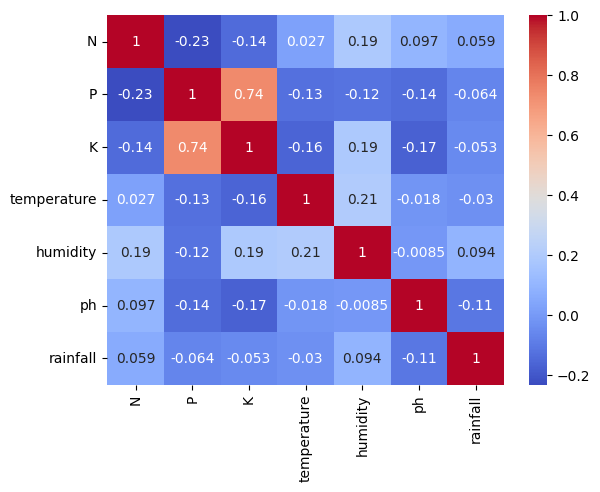

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

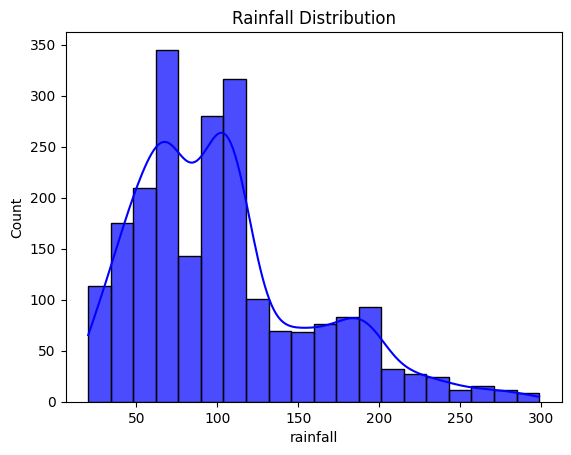

In [ ]:
sns.histplot(
    df['rainfall'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

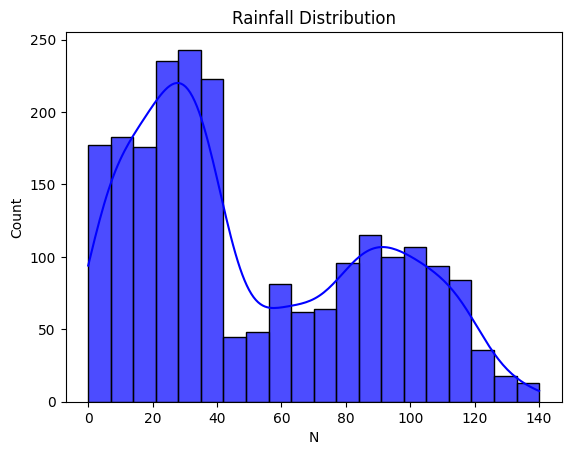

In [ ]:
sns.histplot(
    df['N'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

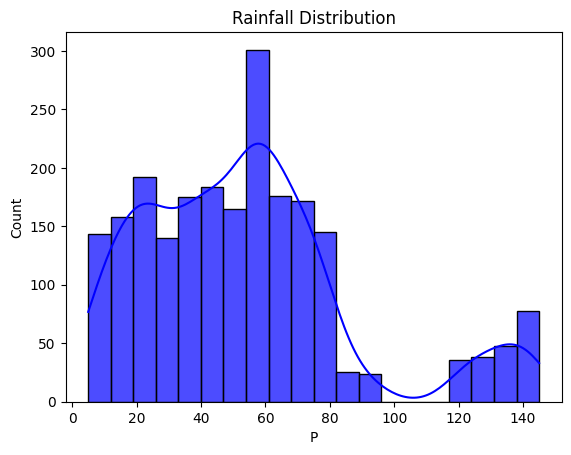

In [ ]:
sns.histplot(
    df['P'],
    bins=20,
    kde=True,
    color='blue',
    edgecolor='black',
    stat='count',
    alpha=0.7
)
plt.title("Rainfall Distribution")
plt.show()

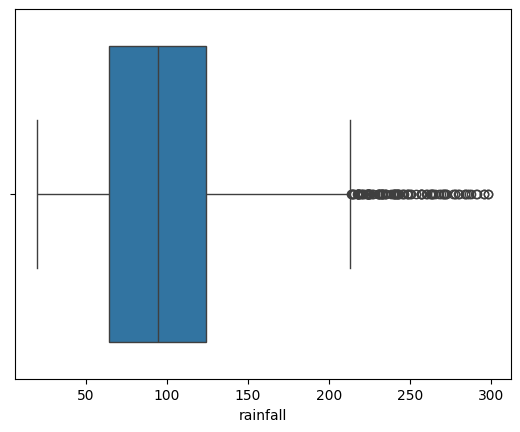

In [ ]:
sns.boxplot(x=df['rainfall'])
plt.show()

In [ ]:
df['rainfall'].skew()

np.float64(0.9657563536272812)

In [ ]:
Q1 = df['rainfall'].quantile(0.25)
Q3 = df['rainfall'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['rainfall'] < lower) | (df['rainfall'] > upper)]
print(lower)
print(upper)
print(outliers['rainfall'])

-25.022046700000033
213.84124050000003
1       226.655537
2       263.964248
3       242.864034
4       262.717340
5       251.055000
           ...    
1867    215.196804
1881    224.831573
1886    213.901102
1892    225.632366
1894    221.225817
Name: rainfall, Length: 100, dtype: float64


In [ ]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'chickpea': 3,
    'kidneybeans': 4,
    'pigeonpeas': 5,
    'mothbeans': 6,
    'mungbean': 7,
    'blackgram': 8,
    'lentil': 9,
    'pomegranate': 10,
    'banana': 11,
    'mango': 12,
    'grapes': 13,
    'watermelon': 14,
    'muskmelon': 15,
    'apple': 16,
    'orange': 17,
    'papaya': 18,
    'coconut': 19,
    'cotton': 20,
    'jute': 21,
    'coffee': 22
}

In [ ]:
df['label'] = df['label'].map(crop_dict)

In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


In [ ]:
X=df.drop('label',axis=1)
y=df['label']

In [ ]:
print(y)


0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: label, Length: 2200, dtype: int64


In [ ]:
print(y)

0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: label, Length: 2200, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(1760, 7)

In [ ]:
X_test.shape

(440, 7)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [ ]:
X_train

array([[-9.03426596e-01, -1.12616170e+00, -6.68506601e-01, ...,
         9.36586183e-01,  1.93473784e-01,  5.14970176e-03],
       [-3.67051340e-01,  7.70358846e-01, -5.70589522e-01, ...,
        -1.00470485e-01,  8.63917548e-01, -6.05290566e-01],
       [-1.17161422e+00,  5.89737842e-01, -4.53089028e-01, ...,
        -3.82774991e-01,  1.05029771e+00, -1.04580687e+00],
       ...,
       [-1.06433917e+00, -5.24091685e-01, -3.35588533e-01, ...,
        -8.98381379e-01, -6.34357580e-04, -4.37358211e-02],
       [-1.06433917e+00,  2.12501638e+00,  3.05234239e+00, ...,
         3.86340190e-01, -1.48467347e-01, -5.69036842e-01],
       [-5.01145154e-01,  7.40255346e-01, -5.11839275e-01, ...,
        -4.18045489e-01,  6.86860180e-01, -8.96531475e-01]])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'SVC':SVC(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(max_depth=8)
}

In [ ]:
results = {}
predictions = {}
train_scores = {}
test_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    train_pred = model.predict(X_train)
    test_acc = accuracy_score(y_test, y_pred)
    train_acc = accuracy_score(y_train, train_pred)
    results[name] = test_acc
    predictions[name] = y_pred
    train_scores[name] = train_acc
    test_scores[name] = test_acc

In [ ]:
for name in models:
    print(f"\n{name}")
    print("Train Accuracy:", train_scores[name])
    print("Test Accuracy :", test_scores[name])


LogisticRegression
Train Accuracy: 0.977840909090909
Test Accuracy : 0.9636363636363636

SVC
Train Accuracy: 0.9880681818181818
Test Accuracy : 0.9681818181818181

KNeighborsClassifier
Train Accuracy: 0.9880681818181818
Test Accuracy : 0.9659090909090909

DecisionTreeClassifier
Train Accuracy: 0.9852272727272727
Test Accuracy : 0.9727272727272728


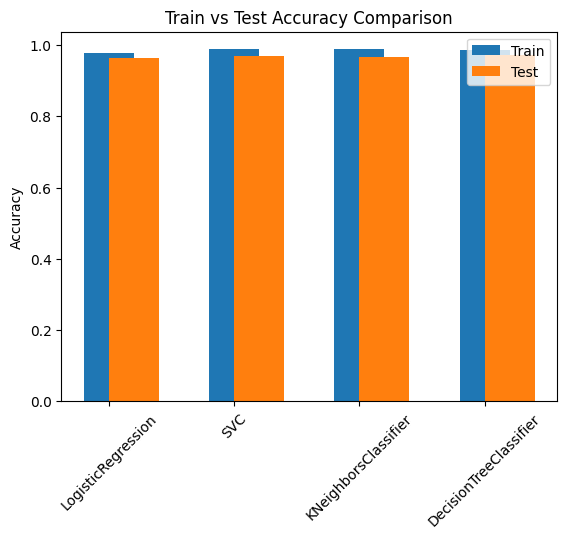

In [ ]:
import matplotlib.pyplot as plt
names = list(models.keys())
train_vals = list(train_scores.values())
test_vals = list(test_scores.values())
x = range(len(names))
plt.bar(x, train_vals, width=0.4, label='Train', align='center')
plt.bar(x, test_vals, width=0.4, label='Test', align='edge')
plt.xticks(x, names, rotation=45)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy Comparison")
plt.legend()
plt.show()

In [ ]:
for name, score in results.items():
    print(name, ":", score)

LogisticRegression : 0.9636363636363636
SVC : 0.9681818181818181
KNeighborsClassifier : 0.9659090909090909
DecisionTreeClassifier : 0.9727272727272728


In [ ]:
data = [
[32,14,37,22.73031253,88.48567856,6.825256236,104.6843243],
[18,21,35,23.2801227,94.94330457,6.368560522,111.1382096],
[8,23,38,19.30106297,87.1775172,7.005410734,105.4766591],
[15,6,41,19.0087067,88.83768149,6.897368477,108.6793978],
[0,5,36,24.35193812,90.88612388,6.152906502,105.529185],
[22,9,44,24.72235539,88.87651295,5.744361602,112.1926517],
[14,8,43,21.92513945,94.46485312,7.051654924,111.7162016],
[31,11,45,24.83954414,86.88738076,6.034612928,107.6435771],
[39,17,45,18.09691127,90.42177379,6.924490731,104.88189],
[10,5,42,20.24104904,91.08706822,6.887005997,109.2537734],
[8,28,38,23.22594,94.42971362,6.8444019,105.6917856],
[32,13,42,23.50128217,92.97527546,5.786058032,106.61905],
[18,9,40,19.44623085,89.02127045,5.627186257,106.1606833],
[20,27,41,20.51343484,92.51675903,5.700088663,110.5764023],
[39,25,36,18.90223032,94.99897537,5.567805185,107.6103211],
[20,7,45,18.90592319,89.24126808,6.077886012,112.4750941],
[11,10,45,22.63045168,88.45577158,6.397995609,109.0357597],
[40,18,43,19.38603815,86.79058496,5.767372539,109.9130984],
[3,26,39,24.38318965,91.19431555,7.079973241,103.6012114],
[9,16,36,23.77989026,92.93386903,5.893332378,106.977723],
[30,20,38,22.59890174,93.16343942,7.058222596,110.0932899]
]

In [ ]:
data_scaled = sc.transform(data)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
reverse_dict = {v: k for k, v in crop_dict.items()}

for name, model in models.items():
    preds = model.predict(data_scaled)
    print(f"\n{name} predictions:")

    for i, p in enumerate(preds):
        print(f"Row {i+1} → {reverse_dict[p]}")


LogisticRegression predictions:
Row 1 → pomegranate
Row 2 → pomegranate
Row 3 → pomegranate
Row 4 → pomegranate
Row 5 → pomegranate
Row 6 → pomegranate
Row 7 → pomegranate
Row 8 → pomegranate
Row 9 → pomegranate
Row 10 → pomegranate
Row 11 → pomegranate
Row 12 → pomegranate
Row 13 → pomegranate
Row 14 → pomegranate
Row 15 → pomegranate
Row 16 → pomegranate
Row 17 → pomegranate
Row 18 → pomegranate
Row 19 → pomegranate
Row 20 → pomegranate
Row 21 → pomegranate

SVC predictions:
Row 1 → pomegranate
Row 2 → pomegranate
Row 3 → pomegranate
Row 4 → pomegranate
Row 5 → pomegranate
Row 6 → pomegranate
Row 7 → pomegranate
Row 8 → pomegranate
Row 9 → pomegranate
Row 10 → pomegranate
Row 11 → pomegranate
Row 12 → pomegranate
Row 13 → pomegranate
Row 14 → pomegranate
Row 15 → pomegranate
Row 16 → pomegranate
Row 17 → pomegranate
Row 18 → pomegranate
Row 19 → pomegranate
Row 20 → pomegranate
Row 21 → pomegranate

KNeighborsClassifier predictions:
Row 1 → pomegranate
Row 2 → pomegranate
Row 3 → po

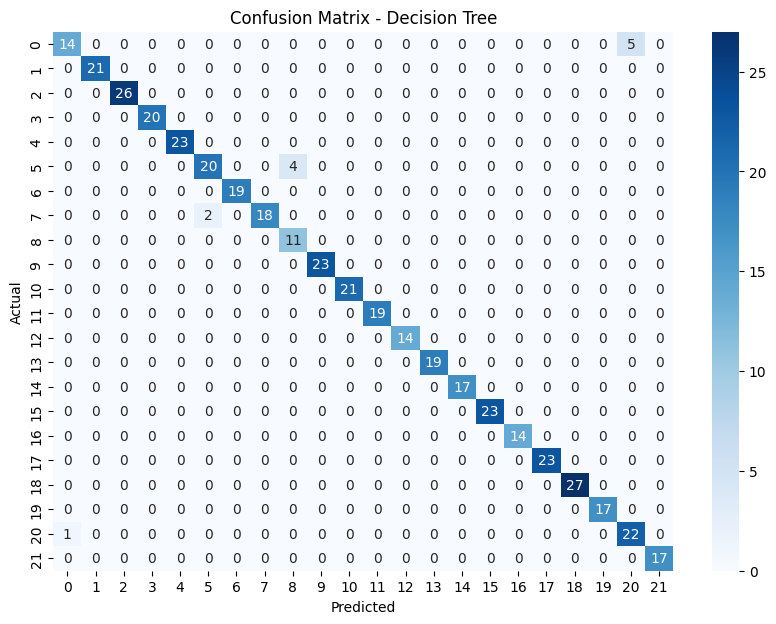

In [ ]:
cm = confusion_matrix(y_test,predictions['DecisionTreeClassifier'])
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

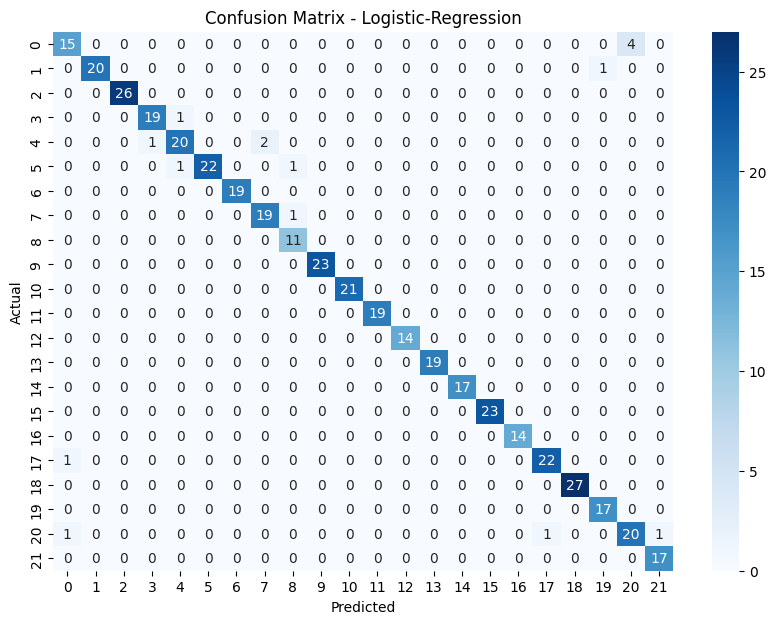

In [ ]:
cm = confusion_matrix(y_test,predictions['LogisticRegression'])
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,cmap='Blues')
plt.title("Confusion Matrix - Logistic-Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

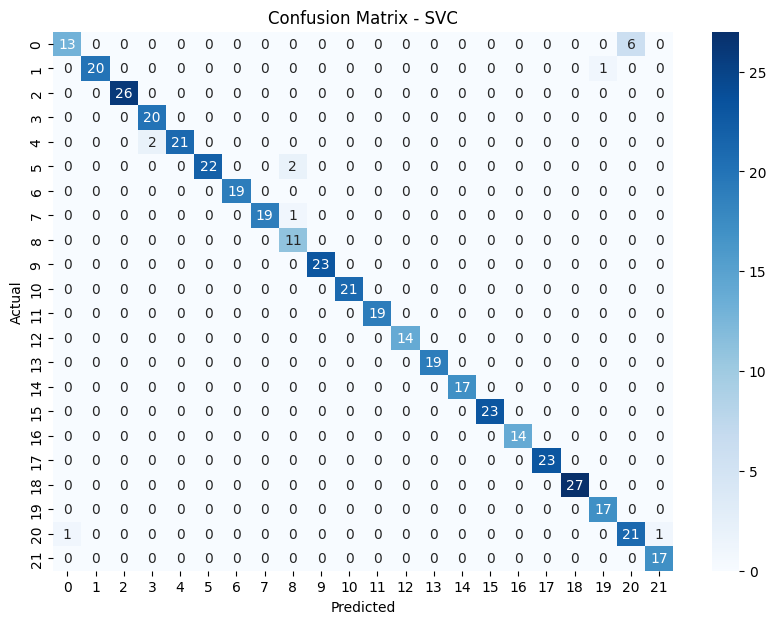

In [ ]:
cm = confusion_matrix(y_test,predictions['SVC'])
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,cmap='Blues')
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

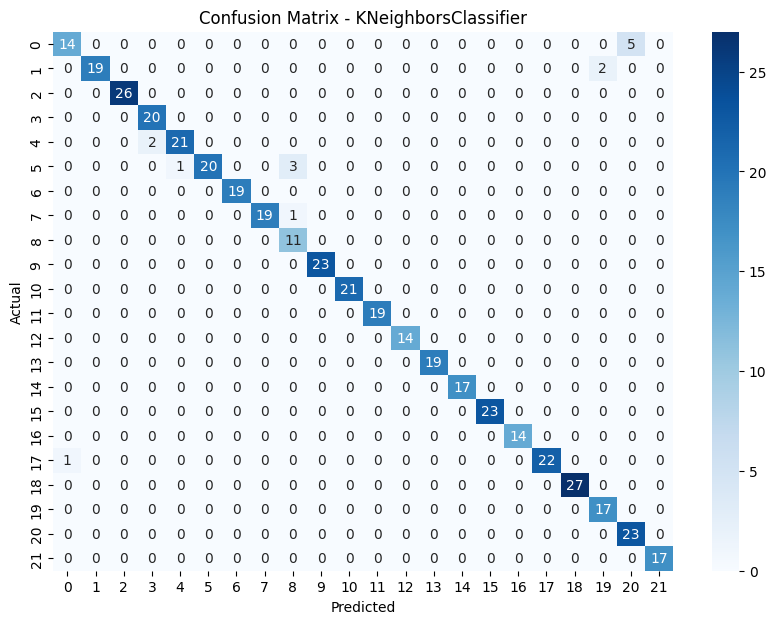

In [ ]:
cm = confusion_matrix(y_test,predictions['KNeighborsClassifier'])
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,cmap='Blues')
plt.title("Confusion Matrix - KNeighborsClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name in predictions:
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, predictions[name]))


LogisticRegression Classification Report:

              precision    recall  f1-score   support

           1       0.88      0.79      0.83        19
           2       1.00      0.95      0.98        21
           3       1.00      1.00      1.00        26
           4       0.95      0.95      0.95        20
           5       0.91      0.87      0.89        23
           6       1.00      0.92      0.96        24
           7       1.00      1.00      1.00        19
           8       0.90      0.95      0.93        20
           9       0.85      1.00      0.92        11
          10       1.00      1.00      1.00        23
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        14
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        23
          17       1.00      1.00    

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier


In [ ]:
estimators = [
    ('svc', SVC(probability=True)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(max_depth=8))
    # ('lr', LogisticRegression(max_iter=1000))
]

In [ ]:
meta_model = RandomForestClassifier(n_estimators=100)

In [ ]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

In [ ]:
stack_model.fit(X_train, y_train)

StackingClassifier(estimators=[('svc', SVC(probability=True)),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(max_depth=8))],
                   final_estimator=RandomForestClassifier())

In [ ]:
y_pred_stack = stack_model.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.9795454545454545


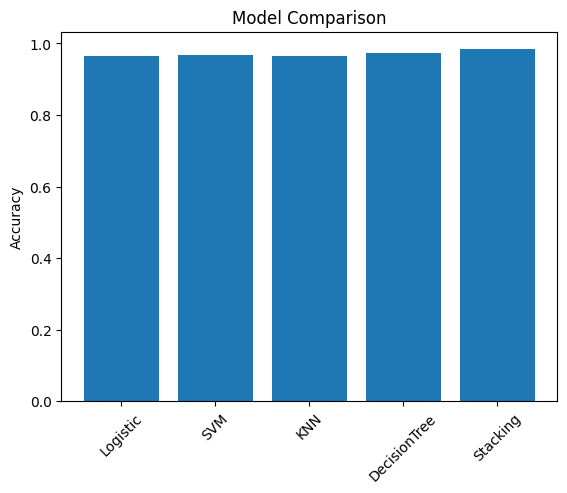

In [ ]:
names = ['Logistic', 'SVM', 'KNN', 'DecisionTree', 'Stacking']
values = [
    results['LogisticRegression'],
    results['SVC'],
    results['KNeighborsClassifier'],
    results['DecisionTreeClassifier'],
    0.984
]

import matplotlib.pyplot as plt

plt.bar(names, values)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

In [ ]:
row = df.iloc[2004]

sample = [[row[col] for col in X.columns]]

sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Actual:", reverse_dict[row['label']])
print("Predicted:", reverse_dict[pred[0]])

Actual: jute
Predicted: jute


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
N = float(input("Enter Nitrogen: "))
P = float(input("Enter Phosphorus: "))
K = float(input("Enter Potassium: "))
temp = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))
sample_dict = {
    'N': N,
    'P': P,
    'K': K,
    'temperature': temp,
    'humidity': humidity,
    'ph': ph,
    'rainfall': rainfall
}

sample = [[sample_dict[col] for col in X.columns]]
sample_scaled = sc.transform(sample)

pred = stack_model.predict(sample_scaled)

reverse_dict = {v:k for k,v in crop_dict.items()}

print("Recommended Crop:", reverse_dict[pred[0]])

Enter Nitrogen: 101
Enter Phosphorus: 31
Enter Potassium: 26
Enter Temperature: 26.70897548
Enter Humidity: 69.71184111
Enter pH: 6.861235184
Enter Rainfall: 158.860888699999
Recommended Crop: coffee


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import os

save_path = "/content/drive/MyDrive/crop_project"
os.makedirs(save_path, exist_ok=True)

print("Folder ready:", save_path)

Folder ready: /content/drive/MyDrive/crop_project


In [ ]:
import joblib

# Level-0 models
joblib.dump(models['LogisticRegression'], f"{save_path}/lr_model.pkl")
joblib.dump(models['SVC'], f"{save_path}/svc_model.pkl")
joblib.dump(models['KNeighborsClassifier'], f"{save_path}/knn_model.pkl")
joblib.dump(models['DecisionTreeClassifier'], f"{save_path}/dt_model.pkl")

# Level-1 model (stacking)
joblib.dump(stack_model, f"{save_path}/stack_model.pkl")

# Scaler + mapping
joblib.dump(sc, f"{save_path}/scaler.pkl")
joblib.dump(crop_dict, f"{save_path}/mapping.pkl")

print("All models saved permanently ✅")

All models saved permanently ✅


In [ ]:
print(os.listdir(save_path))

['lr_model.pkl', 'svc_model.pkl', 'knn_model.pkl', 'dt_model.pkl', 'stack_model.pkl', 'scaler.pkl', 'mapping.pkl']
